**Goal:** reuse a network somebody else trained on a million images. You will load a **pretrained
ResNet18**, build a **residual block** by hand to see the skip connection that makes it deep, then do
**transfer learning** -- freeze the backbone, train a tiny head -- and watch it crush a CNN trained
**from scratch** on the same little CIFAR-10 dataset. Everything runs on CPU in about thirty seconds
(the one-time downloads aside). Pairs with the concept note
[CNN Architectures & Transfer Learning](l19_concept_cnn_architectures_transfer.qmd).

> **Previously:** L18 -- Convolutional Neural Networks (build one from scratch)  |  **Next:** L20 -- Autoencoders & Representation Learning

> This page is the read-only view. To run the lab, open the notebook
> (`l19_lab_cnn_architectures_transfer.ipynb`) -- in Colab via the badge on the concept page, or locally.

## Scenario

You have only a few hundred labeled images per class -- far too few to train a deep CNN from scratch.
But a ResNet18 has already been trained on ImageNet's 1.2 million photos and knows what edges,
textures, and object-parts look like. We will reuse that knowledge: freeze its convolutional
**backbone**, treat it as a fixed feature extractor, and train a small classifier **head** on
CIFAR-10's ten object classes. Then we will train an equivalent CNN from scratch on the same data and
measure how badly it loses.

## Setup

Two cells: the first installs, the second imports, seeds, loads a small CIFAR-10 subset, and defines
helpers. We resize to 96x96 and normalize with the **ImageNet** statistics the pretrained model expects.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships these, so this is effectively a no-op there.
%pip install -q torch torchvision scikit-learn matplotlib
# local, in a terminal (not in the notebook):  uv add torch torchvision scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS + SEEDS + DATA + HELPERS (safe to re-run without re-installing)
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, Subset

torch.manual_seed(42); np.random.seed(42)

# A pretrained model expects its training-time preprocessing: ImageNet normalization, here at 96x96.
IMAGENET_MEAN = [0.485, 0.456, 0.406]; IMAGENET_STD = [0.229, 0.224, 0.225]
tfm = transforms.Compose([transforms.Resize(96), transforms.ToTensor(),
                          transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

train_full = torchvision.datasets.CIFAR10("data", train=True,  download=True, transform=tfm)
test_full  = torchvision.datasets.CIFAR10("data", train=False, download=True, transform=tfm)
CLASSES = train_full.classes

def balanced_subset(ds, per_class, seed=42):
    """A seed-locked subset with `per_class` images from each of the 10 classes (keeps the lab fast)."""
    rng = np.random.RandomState(seed); targets = np.array(ds.targets); idx = []
    for c in range(10):
        idx.extend(rng.choice(np.where(targets == c)[0], per_class, replace=False))
    rng.shuffle(idx)
    return Subset(ds, list(idx))

train_set = balanced_subset(train_full, 100)   # 1000 images: 100 per class
test_set  = balanced_subset(test_full, 100)    # 1000 test images
test_loader = DataLoader(test_set, batch_size=256)

def loader_accuracy(model, loader):
    """Top-1 accuracy of a model over a DataLoader."""
    model.eval(); correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            correct += (model(xb).argmax(1) == yb).sum().item(); total += len(yb)
    return correct / total

print(f"train {len(train_set)} / test {len(test_set)} images; {len(CLASSES)} classes")
print("classes:", CLASSES)

train 1000 / test 1000 images; 10 classes
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


~~~text
train 1000 / test 1000 images; 10 classes
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
~~~

## Step 1: Meet a Pretrained Network

Load ResNet18 with its ImageNet-trained weights. It is built from four stages of **residual blocks**
(`layer1`..`layer4`) and a classifier **head** (`fc`) that outputs 1000 ImageNet classes:

In [3]:
net = resnet18(weights=ResNet18_Weights.DEFAULT)
print("ResNet18 total parameters:", sum(p.numel() for p in net.parameters()))
print("the classifier head:", net.fc)

ResNet18 total parameters: 11689512
the classifier head: Linear(in_features=512, out_features=1000, bias=True)


~~~text
ResNet18 total parameters: 11689512
the classifier head: Linear(in_features=512, out_features=1000, bias=True)
~~~

To reuse it, split the network into a **backbone** (everything except the head) and a fresh **head**
for our 10 classes, and **freeze** the backbone so gradient descent leaves its weights fixed:

In [4]:
backbone = nn.Sequential(*list(net.children())[:-1])   # all of ResNet18 except fc -> outputs [N, 512, 1, 1]
for p in backbone.parameters():
    p.requires_grad = False                            # freeze: these weights will not be updated

head = nn.Linear(512, 10)                              # a new, trainable head for CIFAR-10's 10 classes
print("trainable parameters after freezing the backbone:", sum(p.numel() for p in head.parameters()))

trainable parameters after freezing the backbone: 5130


~~~text
trainable parameters after freezing the backbone: 5130
~~~

We went from 11.7 million parameters to **5,130** trainable ones -- only the new head learns. The
backbone is now a fixed function from an image to 512 features.

## Step 2: A Residual Block by Hand

What makes a network like ResNet trainable at 18, 50, or 150 layers is the **skip connection**. Build
one block -- two convolutions plus a shortcut that adds the input back -- and watch what it does:

In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.relu  = nn.ReLU()
    def forward(self, x):
        out = self.relu(self.conv1(x))
        out = self.conv2(out)
        return self.relu(out + x)          # the skip connection: add the input back before the final ReLU

torch.manual_seed(0)
block = ResidualBlock(8)
x = torch.randn(1, 8, 16, 16)
print("input shape:", tuple(x.shape), "-> output shape:", tuple(block(x).shape))

# Zero the block's conv weights so F(x) = 0; the output should then be exactly relu(x).
for p in block.parameters():
    nn.init.zeros_(p)
print("with F(x)=0, output == relu(x)?", torch.allclose(block(x), torch.relu(x)))

input shape: (1, 8, 16, 16) -> output shape: (1, 8, 16, 16)
with F(x)=0, output == relu(x)? True


~~~text
input shape: (1, 8, 16, 16) -> output shape: (1, 8, 16, 16)
with F(x)=0, output == relu(x)? True
~~~

The block keeps the shape, so blocks can be stacked indefinitely. And when its convolutions output
nothing (`F(x) = 0`), the skip passes the input straight through -- the block falls back to the
**identity**. That is why adding residual blocks never hurts: in the worst case a block does nothing,
instead of corrupting the signal. Real ResNet blocks add batch-norm and sit inside the `net` you loaded
in Step 1.

## Step 3: Transfer Learning = Feature Extraction

Run every image through the frozen backbone **once** to get its 512 features, then train the small head
on those features. Because the backbone never changes, we can extract the features ahead of time and
the head trains in a blink:

In [6]:
def extract_features(dataset):
    """Run the frozen backbone over a dataset -> (features [N, 512], labels [N])."""
    loader = DataLoader(dataset, batch_size=128, shuffle=False)
    feats, labels = [], []
    backbone.eval()
    with torch.no_grad():
        for xb, yb in loader:
            feats.append(backbone(xb).flatten(1)); labels.append(yb)
    return torch.cat(feats), torch.cat(labels)

Xtr, ytr = extract_features(train_set)
Xte, yte = extract_features(test_set)
print("feature matrix:", tuple(Xtr.shape))

torch.manual_seed(42)
head = nn.Linear(512, 10)
opt = torch.optim.Adam(head.parameters(), lr=1e-3); loss_fn = nn.CrossEntropyLoss()
for step in range(60):
    opt.zero_grad(); loss = loss_fn(head(Xtr), ytr); loss.backward(); opt.step()
    if step % 20 == 0:
        print(f"step {step:2d}  loss {loss.item():.3f}")
print(f"transfer-learning test accuracy: {(head(Xte).argmax(1) == yte).float().mean().item():.4f}")

feature matrix: (1000, 512)
step  0  loss 2.822
step 20  loss 0.775
step 40  loss 0.448
transfer-learning test accuracy: 0.7310


~~~text
feature matrix: (1000, 512)
step  0  loss 2.822
step 20  loss 0.775
step 40  loss 0.448
transfer-learning test accuracy: 0.7310
~~~

With **1000 training images** and a head of 5,130 weights, transfer learning reaches about **0.73**
accuracy on ten classes -- and it took seconds, because the expensive part (the backbone) was reused,
not trained.

## Step 4: Why Bother? Train From Scratch Instead

Now build an equivalent CNN -- the L18 recipe, sized for 96x96 inputs -- and train it on the **same**
1000 images, with no pretrained weights:

In [7]:
def make_scratch_cnn():
    return nn.Sequential(
        nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),    # 96 -> 48
        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 48 -> 24
        nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 24 -> 12
        nn.Flatten(),
        nn.Linear(64 * 12 * 12, 128), nn.ReLU(),                       # 64*12*12 = 9216
        nn.Linear(128, 10),
    )

torch.manual_seed(42)
scratch = make_scratch_cnn()
opt = torch.optim.Adam(scratch.parameters(), lr=1e-3); loss_fn = nn.CrossEntropyLoss()
scratch_loader = DataLoader(train_set, batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(42))
curve = []
for epoch in range(12):
    scratch.train(); running = 0.0
    for xb, yb in scratch_loader:
        opt.zero_grad(); loss = loss_fn(scratch(xb), yb); loss.backward(); opt.step()
        running += loss.item() * len(xb)
    curve.append(running / len(train_set))
print(f"from-scratch CNN test accuracy: {loader_accuracy(scratch, test_loader):.4f}")
print("loss curve:", " ".join(f"{l:.2f}" for l in curve))

from-scratch CNN test accuracy: 0.4190
loss curve: 2.16 1.84 1.60 1.37 1.10 0.82 0.64 0.40 0.24 0.14 0.08 0.06


~~~text
from-scratch CNN test accuracy: 0.4190
loss curve: 2.16 1.84 1.60 1.37 1.10 0.82 0.64 0.40 0.24 0.14 0.08 0.06
~~~

The from-scratch CNN reaches only about **0.42** -- a gap of roughly **0.31** below transfer learning,
on identical data. It is not a bad network; 1000 images is simply far too few to learn good visual
features from nothing. Transfer learning skips that bottleneck by reusing features ImageNet already
paid for.

Before plotting, read the from-scratch CNN's flattened dimension straight off its spatial trace -- the
one number you must get right to wire conv layers into a dense head:

In [8]:
# Your turn (warm-up): from the 96 -> 48 -> 24 -> 12 trace, predict the flattened size that feeds the
# first dense layer, then check it. Uncomment and fill the blank:
# flat_dim = ____                              # 64 feature maps of 12 x 12
# assert flat_dim == scratch[10].in_features   # scratch[10] is the first nn.Linear
# print("flattened dimension:", flat_dim)

The blank is `64 * 12 * 12`, which is `9216` -- the `in_features` of the first `nn.Linear`.

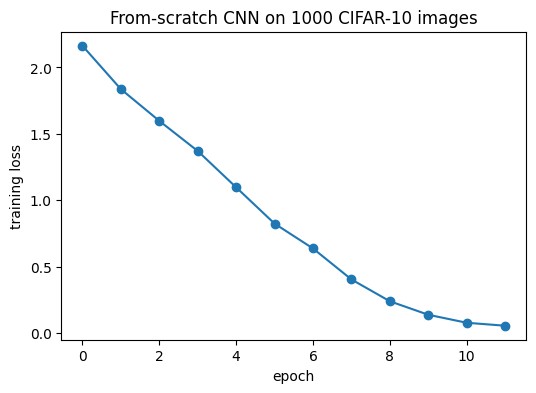

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(curve, marker="o")
plt.xlabel("epoch"); plt.ylabel("training loss")
plt.title("From-scratch CNN on 1000 CIFAR-10 images"); plt.show()

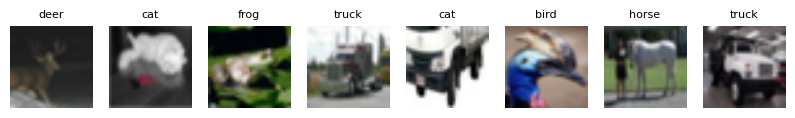

In [10]:
# a few test images with the transfer-learning model's predictions
xb, yb = next(iter(test_loader))
with torch.no_grad():
    pred = head(backbone(xb[:8]).flatten(1)).argmax(1)
plt.figure(figsize=(10, 2))
for i in range(8):
    img = xb[i].permute(1, 2, 0) * torch.tensor(IMAGENET_STD) + torch.tensor(IMAGENET_MEAN)  # un-normalize
    plt.subplot(1, 8, i + 1); plt.imshow(img.clamp(0, 1)); plt.axis("off")
    plt.title(CLASSES[pred[i]][:6], fontsize=8)
plt.show()

## Your Turn

### Exercise 1 -- Fine-tuning

Feature extraction froze the *entire* backbone. **Fine-tuning** unfreezes the top block to let backprop
adapt the high-level features. Reload a fresh `resnet18(weights=ResNet18_Weights.DEFAULT)`, freeze it,
replace `fc` with `nn.Linear(512, 10)`, then set `requires_grad = True` on `model.layer4` and the new
`fc`. Train end-to-end on `train_set` for ~4 epochs at a **low** `lr=1e-4` and report test accuracy.

**Hint:** start with `torch.manual_seed(42)`, *then* reload
`resnet18(weights=ResNet18_Weights.DEFAULT)`, freeze it, set `model.fc = nn.Linear(512, 10)`, and
`for p in model.layer4.parameters(): p.requires_grad = True` -- seeding first fixes the new head's
initialization so your number matches the reveal exactly. Collect the trainable parameters with
`[p for p in model.parameters() if p.requires_grad]` and pass them to `Adam(..., lr=1e-4)`; reuse a
`DataLoader(train_set, batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(42))` and
`loader_accuracy(...)`. Fine-tuning trains *through* the backbone, so it is slower than Step 3 (about 15 s).

In [11]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
fine-tuned (layer4 + head) test accuracy: 0.7090
~~~

Unfreezing `layer4` makes about **8.4 million** parameters trainable, and after 4 epochs at lr=1e-4 the
model reaches about **0.71** -- essentially the same as feature extraction's 0.73, **not better**. That
is the honest lesson: with only 100 images per class there is too little data to improve the pretrained
features, and fine-tuning risks disturbing them. Fine-tuning pays off when you have *more* data; with
little data, freezing everything (feature extraction) is the right call. With the `torch.manual_seed(42)`
from the hint you should get exactly this number; the takeaway is the comparison, not the last digit.
</details>

### Exercise 2 -- The Head Is Just a Classifier

The frozen backbone turned each image into 512 features; the head is an ordinary classifier on those
features. Prove it: import `from sklearn.linear_model import LogisticRegression`, fit it on the cached
features `Xtr, ytr` from Step 3 (`.numpy()`), and score it on `Xte, yte`. How does it compare to the
`nn.Linear` head?

**Hint:** `LogisticRegression(max_iter=1000).fit(Xtr.numpy(), ytr.numpy())`, then compare
`clf.predict(Xte.numpy())` to `yte.numpy()`. No neural-network training at all -- it is the logistic
regression of Unit II (L04), now on features a CNN extracted.

In [12]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
logistic-regression head test accuracy: 0.7360
~~~

About **0.74** -- essentially identical to the `nn.Linear` head's 0.73. The choice of classifier on top
barely matters; the win lives entirely in the **features** the pretrained backbone produced. "Transfer
learning" is mostly "let a pretrained CNN turn images into good features, then run any classifier you
like" -- including the logistic regression you met in Unit II.
</details>

## Summary

- A **pretrained** ResNet18 (11.7M parameters, an ImageNet head of 1000 classes) splits into a reusable
  conv **backbone** and a task-specific **head**. **Freezing** the backbone left only **5,130**
  trainable parameters.
- A **residual block** (two convs plus a skip) keeps its input shape and falls back to the **identity**
  when `F(x) = 0` -- the trick that lets ResNet go very deep.
- **Transfer learning** as feature extraction -- frozen backbone, trained head -- reached **0.73** on a
  1000-image CIFAR-10 subset, while an equivalent CNN trained **from scratch** managed only **0.42**
  (a ~0.31 gap) on the same data.
- **Fine-tuning** the top block did not beat feature extraction here (~0.71): with little data, freeze
  everything. And the head is just a classifier -- a **logistic-regression** head scored the same
  (~0.74), because the features carry the win.
- Next (L20): instead of reusing features learned from *labels*, **autoencoders** learn useful features
  with no labels at all.